In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)
print('selected_font:', selected_font)


selected_font: AppleGothic


## 6개 스테이션 통합 실행 Baseline

이 노트북은 6개 스테이션을 한 번에 처리하면서 `K=3, 군집당 대표 월 1개, Baseline` 시나리오 폴더에 함께 두기 위한 통합 baseline 파일입니다.

### 포함 범위
- 각 스테이션 `2024 train / valid`, `2025 test` 데이터 구성
- 개별 스테이션 `RandomForest` baseline 학습 및 점수
- 6개 스테이션 통합 `RandomForest` baseline 학습 및 점수
- 개별 모델 vs 통합 모델 비교 표와 그래프

### 비고
- 이 통합 파일은 군집 기반 대표 월 선택이 아니라, 6개 스테이션 전체 baseline 비교용입니다.
- 단일 스테이션 세부 실험은 같은 폴더 안의 개별 노트북을 사용합니다.


In [2]:
station_info = {
    'ST-481': '상현',
    'ST-2425': '다원',
    'ST-1331': '찬솔',
    'ST-454': '신영',
    'ST-453': '혜전',
    'ST-1482': '광태',
}
station_ids = list(station_info.keys())
base_path = Path('../../../Data/sort_data/preprocessed_6station')
feature_cols = [
    '온도', '습도', '강수량', 'snow_flag', 'is_restingday',
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos'
]
static_cols = [
    '위도', '경도', 'residential_index', 'business_index',
    'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index'
]
target_col = 'total_flow'
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, None],
    'min_samples_leaf': [1, 3, 5],
}
search_cv = TimeSeriesSplit(n_splits=4)
print('station_ids:', station_ids)
print('target_col:', target_col)


station_ids: ['ST-481', 'ST-2425', 'ST-1331', 'ST-454', 'ST-453', 'ST-1482']
target_col: total_flow


In [3]:
def load_station_csv(station_id, year_suffix=''):
    path = base_path / f'{station_id}{year_suffix}.csv'
    df = pd.read_csv(path)
    df = df.loc[~df['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    else:
        df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
        df['timestamp'] = df['기준_날짜'] + pd.to_timedelta(df['시간대'], unit='h')
    return df
def make_station_hourly(raw_df, feature_columns, add_static=True):
    agg_map = {
        'inflow': ('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
        'outflow': ('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
    }
    for col in feature_columns:
        agg_map[col] = (col, 'first')
    if add_static:
        for col in static_cols:
            if col in raw_df.columns:
                agg_map[col] = (col, 'first')
    if 'station_id' in raw_df.columns:
        agg_map['station_id'] = ('station_id', 'first')
    hourly_df = raw_df.sort_values('timestamp').groupby('timestamp').agg(**agg_map)
    full_idx = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
    hourly_df = hourly_df.reindex(full_idx)
    hourly_df.index.name = 'timestamp'
    hourly_df[['inflow', 'outflow']] = hourly_df[['inflow', 'outflow']].fillna(0)
    fill_forward_cols = [c for c in hourly_df.columns if c not in ['inflow', 'outflow']]
    for col in fill_forward_cols:
        hourly_df[col] = hourly_df[col].ffill().bfill()
    hourly_df = hourly_df.reset_index()
    hourly_df['total_flow'] = hourly_df['inflow'] + hourly_df['outflow']
    hourly_df['net_flow'] = hourly_df['inflow'] - hourly_df['outflow']
    return hourly_df
def split_train_valid(hourly_df, train_ratio=0.7):
    split_idx = int(len(hourly_df) * train_ratio)
    train_df = hourly_df.iloc[:split_idx].copy()
    valid_df = hourly_df.iloc[split_idx:].copy()
    return train_df, valid_df
def score_regression(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
    }


## 개별 스테이션 데이터 준비

각 스테이션마다:
- `2024` 데이터를 시간대별 `total_flow`로 집계
- `2025` 데이터를 외부 테스트용 시간대 데이터로 집계
- `2024` 내부를 `train 70% / valid 30%`로 분리


In [4]:
station_datasets = {}
station_static_map = {}
station_split_summary = []
for station_id in station_ids:
    train_raw = load_station_csv(station_id, '')
    test_raw = load_station_csv(station_id, '_2025')
    train_hourly = make_station_hourly(train_raw, feature_cols, add_static=True)
    station_static_map[station_id] = {col: train_hourly[col].iloc[0] for col in static_cols if col in train_hourly.columns}
    test_hourly = make_station_hourly(test_raw, feature_cols, add_static=True)
    for col, value in station_static_map[station_id].items():
        if col not in test_hourly.columns:
            test_hourly[col] = value
    train_df, valid_df = split_train_valid(train_hourly, train_ratio=0.7)
    station_datasets[station_id] = {
        'train': train_df,
        'valid': valid_df,
        'test': test_hourly,
    }
    station_split_summary.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'train_rows': len(train_df),
        'valid_rows': len(valid_df),
        'test_rows': len(test_hourly),
        'train_start': train_df['timestamp'].min(),
        'train_end': train_df['timestamp'].max(),
        'test_start': test_hourly['timestamp'].min(),
        'test_end': test_hourly['timestamp'].max(),
    })
station_split_summary = pd.DataFrame(station_split_summary)
display(station_split_summary)


,station_id,station_name,train_rows,valid_rows,test_rows,train_start,train_end,test_start,test_end
0,ST-481,상현,6148,2636,8567,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
1,ST-2425,다원,6147,2635,8567,2024-01-01 01:00:00,2024-09-13 03:00:00,2025-01-09 01:00:00,2025-12-31 23:00:00
2,ST-1331,찬솔,6148,2636,8568,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
3,ST-454,신영,6148,2636,8568,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
4,ST-453,혜전,6148,2635,8567,2024-01-01 01:00:00,2024-09-13 04:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
5,ST-1482,광태,6148,2636,2844,2024-01-01 00:00:00,2024-09-13 03:00:00,2025-01-09 00:00:00,2025-05-07 11:00:00


## 개별 스테이션 RandomForest 학습 및 점수

각 스테이션별로 `GridSearchCV`를 통해 `RandomForest` 최적 파라미터를 찾고,
같은 스테이션의 `valid`와 `2025 test` 점수를 계산합니다.


In [5]:
station_model_results = []
station_best_models = {}
for station_id in station_ids:
    train_df = station_datasets[station_id]['train']
    valid_df = station_datasets[station_id]['valid']
    test_df = station_datasets[station_id]['test']
    search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=search_cv,
        n_jobs=1,
    )
    search.fit(train_df[feature_cols], train_df[target_col])
    best_model = search.best_estimator_
    pred_train = best_model.predict(train_df[feature_cols])
    pred_valid = best_model.predict(valid_df[feature_cols])
    pred_test = best_model.predict(test_df[feature_cols])
    train_score = score_regression(train_df[target_col], pred_train)
    valid_score = score_regression(valid_df[target_col], pred_valid)
    test_score = score_regression(test_df[target_col], pred_test)
    station_best_models[station_id] = best_model
    station_model_results.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'best_params': str(search.best_params_),
        'train_R2': train_score['R2'],
        'valid_R2': valid_score['R2'],
        'test_R2': test_score['R2'],
        'train_MAE': train_score['MAE'],
        'valid_MAE': valid_score['MAE'],
        'test_MAE': test_score['MAE'],
        'train_RMSE': train_score['RMSE'],
        'valid_RMSE': valid_score['RMSE'],
        'test_RMSE': test_score['RMSE'],
    })
station_model_results = pd.DataFrame(station_model_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(station_model_results.round(4))


,station_id,station_name,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.7343,0.6207,0.6210,3.7619,4.5403,4.5323,5.1426,6.1692,6.0223
1,ST-1331,찬솔,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.8638,0.6098,0.5995,2.2564,3.9009,4.2216,3.1051,5.4382,5.8152
2,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.7968,0.5430,0.5193,2.4741,3.5451,3.6717,3.3842,4.7003,4.8557
3,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.8856,0.5299,0.4399,2.6106,4.6769,4.8158,3.6069,6.1694,6.4699
4,ST-2425,다원,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.5943,0.4184,0.4115,2.3481,2.7794,2.7214,3.2359,3.7279,3.6078
5,ST-1482,광태,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.5635,0.3896,0.2347,2.4159,2.7432,2.5189,3.2242,3.5440,3.2127


In [6]:
print('개별 스테이션 테스트 R2 비교')
display(station_model_results[['station_id', 'station_name', 'best_params', 'test_R2']].round(4))
print('개별 스테이션 테스트 MAE 비교')
display(station_model_results[['station_id', 'station_name', 'test_MAE']].round(4))
print('개별 스테이션 테스트 RMSE 비교')
display(station_model_results[['station_id', 'station_name', 'test_RMSE']].round(4))


개별 스테이션 테스트 R2 비교


,station_id,station_name,best_params,test_R2
0,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.6210
1,ST-1331,찬솔,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.5995
2,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.5193
3,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.4399
4,ST-2425,다원,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.4115
5,ST-1482,광태,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.2347


개별 스테이션 테스트 MAE 비교


,station_id,station_name,test_MAE
0,ST-454,신영,4.5323
1,ST-1331,찬솔,4.2216
2,ST-481,상현,3.6717
3,ST-453,혜전,4.8158
4,ST-2425,다원,2.7214
5,ST-1482,광태,2.5189


개별 스테이션 테스트 RMSE 비교


,station_id,station_name,test_RMSE
0,ST-454,신영,6.0223
1,ST-1331,찬솔,5.8152
2,ST-481,상현,4.8557
3,ST-453,혜전,6.4699
4,ST-2425,다원,3.6078
5,ST-1482,광태,3.2127


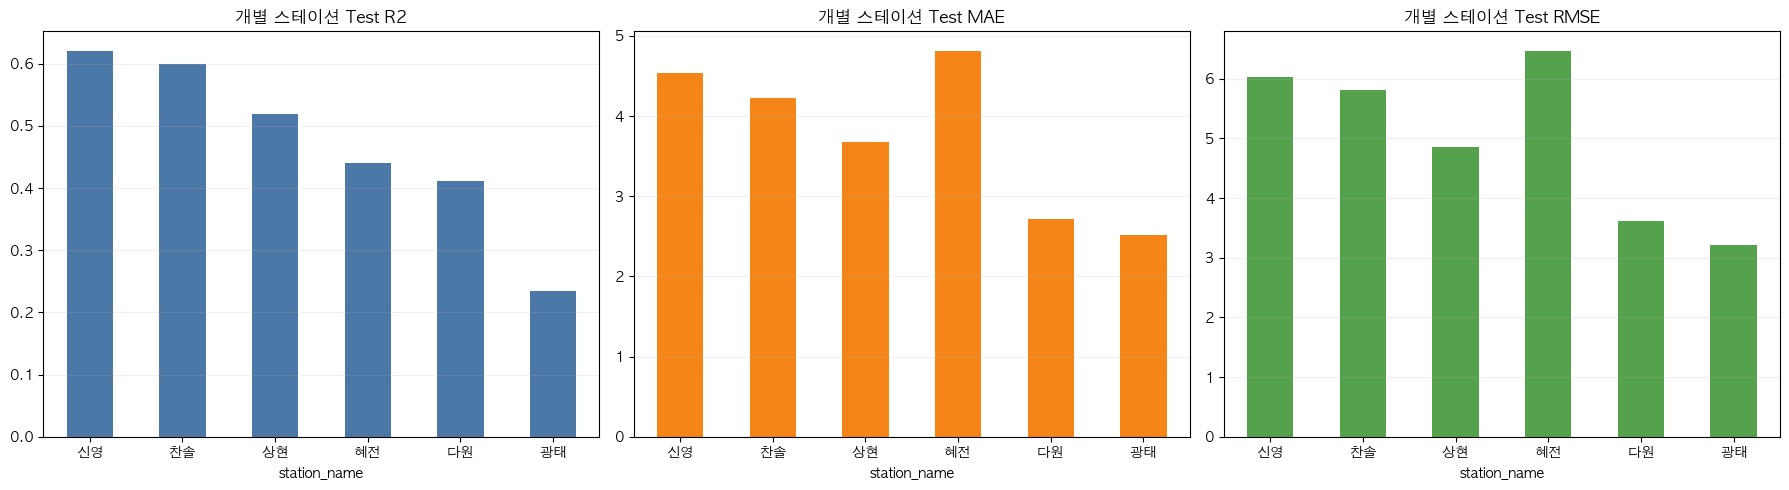

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = station_model_results.set_index('station_name')
plot_df['test_R2'].plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('개별 스테이션 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
plot_df['test_MAE'].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('개별 스테이션 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
plot_df['test_RMSE'].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('개별 스테이션 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6개 스테이션 통합 데이터 구성

통합 모델은 6개 스테이션의 `2024 train`, `2024 valid`, `2025 test`를 각각 합친 뒤,
`station_id`를 원-핫 인코딩해서 하나의 모델로 학습합니다.


In [8]:
combined_train = pd.concat([station_datasets[s]['train'] for s in station_ids], ignore_index=True)
combined_valid = pd.concat([station_datasets[s]['valid'] for s in station_ids], ignore_index=True)
combined_test = pd.concat([station_datasets[s]['test'] for s in station_ids], ignore_index=True)
combined_feature_cols = feature_cols + static_cols + ['station_id']
X_train_combined = pd.get_dummies(combined_train[combined_feature_cols], columns=['station_id'])
X_valid_combined = pd.get_dummies(combined_valid[combined_feature_cols], columns=['station_id'])
X_test_combined = pd.get_dummies(combined_test[combined_feature_cols], columns=['station_id'])
X_valid_combined = X_valid_combined.reindex(columns=X_train_combined.columns, fill_value=0)
X_test_combined = X_test_combined.reindex(columns=X_train_combined.columns, fill_value=0)
y_train_combined = combined_train[target_col]
y_valid_combined = combined_valid[target_col]
y_test_combined = combined_test[target_col]
print('combined_train:', X_train_combined.shape)
print('combined_valid:', X_valid_combined.shape)
print('combined_test:', X_test_combined.shape)


combined_train: (36887, 23)
combined_valid: (15814, 23)
combined_test: (45681, 23)


## 6개 스테이션 통합 RandomForest 학습 및 점수

통합 모델도 같은 파라미터 탐색 범위를 사용합니다.
최종적으로:
- 통합 전체 점수
- 통합 모델의 스테이션별 테스트 점수
를 같이 확인합니다.


In [9]:
combined_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=search_cv,
    n_jobs=1,
)
combined_search.fit(X_train_combined, y_train_combined)
combined_best_model = combined_search.best_estimator_
combined_pred_train = combined_best_model.predict(X_train_combined)
combined_pred_valid = combined_best_model.predict(X_valid_combined)
combined_pred_test = combined_best_model.predict(X_test_combined)
combined_scores = pd.DataFrame([{
    'scope': '6개 통합',
    'best_params': str(combined_search.best_params_),
    'train_R2': r2_score(y_train_combined, combined_pred_train),
    'valid_R2': r2_score(y_valid_combined, combined_pred_valid),
    'test_R2': r2_score(y_test_combined, combined_pred_test),
    'train_MAE': mean_absolute_error(y_train_combined, combined_pred_train),
    'valid_MAE': mean_absolute_error(y_valid_combined, combined_pred_valid),
    'test_MAE': mean_absolute_error(y_test_combined, combined_pred_test),
    'train_RMSE': mean_squared_error(y_train_combined, combined_pred_train) ** 0.5,
    'valid_RMSE': mean_squared_error(y_valid_combined, combined_pred_valid) ** 0.5,
    'test_RMSE': mean_squared_error(y_test_combined, combined_pred_test) ** 0.5,
}])
display(combined_scores.round(4))


,scope,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,6개 통합,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.6824,0.5673,0.5502,3.4961,3.9295,3.9671,4.8,5.3254,5.5143


In [10]:
combined_test_with_pred = combined_test[['station_id', 'timestamp', target_col]].copy()
combined_test_with_pred['pred_total_flow'] = combined_pred_test
combined_station_scores = []
for station_id in station_ids:
    station_slice = combined_test_with_pred[combined_test_with_pred['station_id'] == station_id].copy()
    combined_station_scores.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[target_col], station_slice['pred_total_flow']),
        'test_MAE': mean_absolute_error(station_slice[target_col], station_slice['pred_total_flow']),
        'test_RMSE': mean_squared_error(station_slice[target_col], station_slice['pred_total_flow']) ** 0.5,
    })
combined_station_scores = pd.DataFrame(combined_station_scores).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(combined_station_scores.round(4))


,station_id,station_name,test_R2,test_MAE,test_RMSE
0,ST-454,신영,0.5944,4.6971,6.2298
1,ST-481,상현,0.5021,3.7152,4.9416
2,ST-1331,찬솔,0.4980,4.4551,6.5103
3,ST-453,혜전,0.4721,4.6217,6.2809
4,ST-2425,다원,0.3798,2.8262,3.7038
5,ST-1482,광태,0.2517,2.5218,3.1768


In [11]:
print('개별 모델 vs 통합 모델 비교용 표')
compare_station_vs_combined = station_model_results[['station_id', 'station_name', 'test_R2', 'test_MAE', 'test_RMSE']].merge(
    combined_station_scores,
    on=['station_id', 'station_name'],
    suffixes=('_individual', '_combined')
)
display(compare_station_vs_combined.round(4))


개별 모델 vs 통합 모델 비교용 표


,station_id,station_name,test_R2_individual,test_MAE_individual,test_RMSE_individual,test_R2_combined,test_MAE_combined,test_RMSE_combined
0,ST-454,신영,0.6210,4.5323,6.0223,0.5944,4.6971,6.2298
1,ST-1331,찬솔,0.5995,4.2216,5.8152,0.4980,4.4551,6.5103
2,ST-481,상현,0.5193,3.6717,4.8557,0.5021,3.7152,4.9416
3,ST-453,혜전,0.4399,4.8158,6.4699,0.4721,4.6217,6.2809
4,ST-2425,다원,0.4115,2.7214,3.6078,0.3798,2.8262,3.7038
5,ST-1482,광태,0.2347,2.5189,3.2127,0.2517,2.5218,3.1768


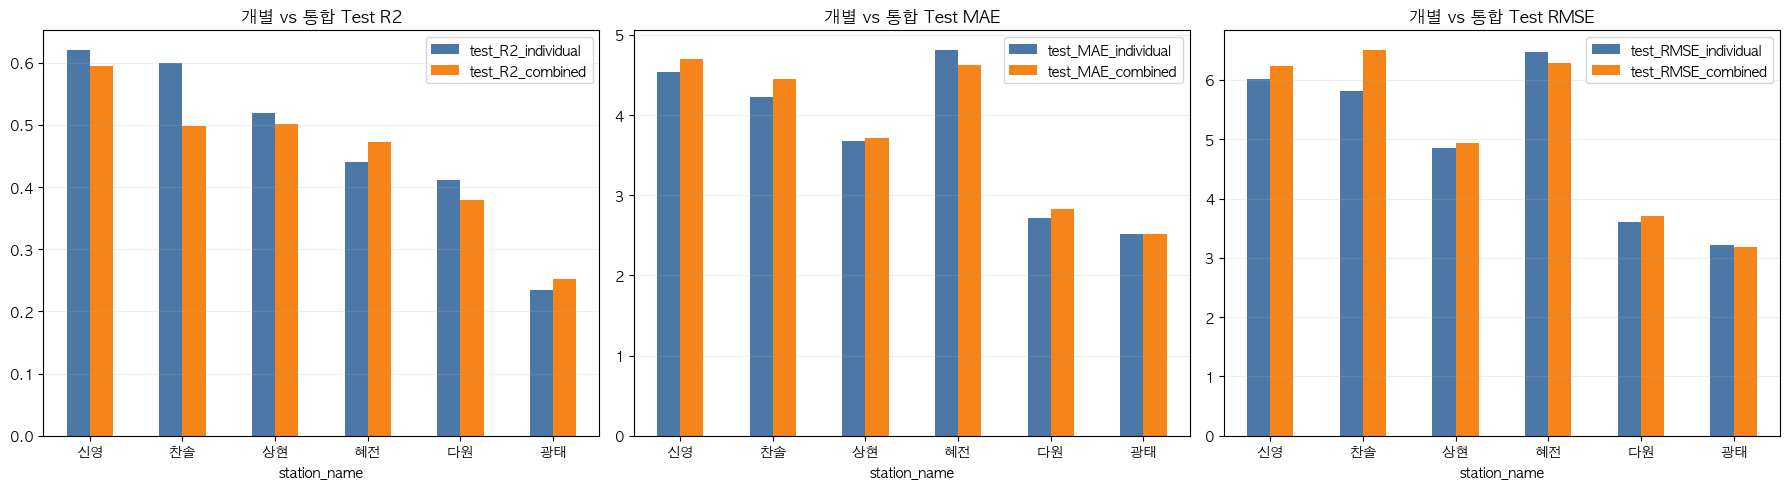

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
compare_df = compare_station_vs_combined.set_index('station_name')
compare_df[['test_R2_individual', 'test_R2_combined']].plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('개별 vs 통합 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
compare_df[['test_MAE_individual', 'test_MAE_combined']].plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('개별 vs 통합 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
compare_df[['test_RMSE_individual', 'test_RMSE_combined']].plot(kind='bar', ax=axes[2], color=['#4C78A8', '#F58518'])
axes[2].set_title('개별 vs 통합 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
